In [1]:
import numpy as np
# import density_field_library as DFL
import matplotlib.pyplot as plt
from math import pi

import Pk_library as PKL
import config as config
import my_remote_spectra as remote_spectra
# import remote_spectra as remote_spectra
import kszpsz_config as kszpsz_config

import importlib
# from scipy.interpolate import RegularGridInterpolator
# from scipy.interpolate import interp1d
import healpy as hp
import my_tools

In [2]:
Omega_b = config.Omega_b
Omega_c = config.Omega_c
w = config.w
wa = config.wa
Omega_K = config.Omega_K
h = config.h
As= config.As
ns = config.ns

In [3]:
grid              = 64  #grid size
BoxSize           = 30000 #Mpc
seed              = 1    #value of the initial random seed # varing seed
Rayleigh_sampling = 0     #whether sampling the Rayleigh distribution for modes amplitudes
threads           = 1      #number of openmp threads
verbose           = True   #whether to print some information

d = BoxSize/grid #Mpc
SampleRate = 1/d #1/Mpc
Max_k = 1/2*2*pi*SampleRate #h/Mpc, 2 from Nyquist theorem
Min_k = 2*pi/BoxSize #1/Mpc
print(f'd={d} Mpc') #Mpc/1
print(f'k_min = {Min_k} 1/Mpc') #1/Mpc
print(f'k_max = {Max_k} 1/Mpc') #1/Mpc

# k calculated by pylian3
kF,kN,kmax_par,kmax_per,kmax = PKL.frequencies(BoxSize, grid)
print(kF) #1/Mpc
print(kN) #1/Mpc

d=468.75 Mpc
k_min = 0.00020943951023931953 1/Mpc
k_max = 0.006702064327658226 1/Mpc
0.00020943951023931953
0.006702064327658225


In [4]:
# 3-d real space axes
d = BoxSize/grid #Mpc
x = np.arange(-BoxSize/2, BoxSize/2, d) #Mpc
y = np.arange(-BoxSize/2, BoxSize/2, d) #Mpc
z = np.arange(-BoxSize/2, BoxSize/2, d) #Mpc
# 3-d meshgrid coordinate 
# xx, yy = np.meshgrid(x, y)
xx, yy, zz = np.meshgrid(x, y, z, indexing='ij')
rr = np.sqrt(xx**2 + yy**2 + zz**2)
print(xx.shape)

(64, 64, 64)


In [5]:
factor = 2*pi
k_x = factor*np.fft.fftfreq(grid, d)
k_y = factor*np.fft.fftfreq(grid, d)
k_z = factor*np.fft.fftfreq(grid, d)
kk_x, kk_y, kk_z = np.meshgrid(k_x, k_y, k_z, indexing='ij')
kk  = np.sqrt(kk_x**2 + kk_y**2 + kk_z**2)
    
# kk_x_s, kk_y_s, kk_z_s = np.fft.fftshift(kk_x), np.fft.fftshift(kk_y), np.fft.fftshift(kk_z)
# kk_s  = np.sqrt(kk_x_s**2 + kk_y_s**2 + kk_z_s**2)
print(kk.shape)

(64, 64, 64)


# Import bubble collision parameters

In [6]:
# Now let's add the inhomogeneous potential psi_i_x where i for inhomogeneous
import param
importlib.reload(param)
A = param.A
B = param.B
direction = param.direction
z_c = param.z_c

A = 1
B = 0
direction = 'z'
z_c = 0
x_c = remote_spectra.chifromz(z_c) #Mpc
r_H = param.r_H #Mpc

Z_e = 1
a_e = 1/(1+Z_e)

if 1:
    print(A)
    print(B)
    print(z_c)
    print(x_c)
    print(f'r_H = {r_H} Mpc') #Mpc

1
0
0
0.0
r_H = 4411.764705882353 Mpc


[2.66122412e-08 7.91397325e-08 2.27216329e-07 6.29819837e-07
 1.68548529e-06 4.35477209e-06 1.08626986e-05 2.61602485e-05
 6.08244001e-05 1.36535517e-04 2.95900212e-04 6.19122731e-04
 1.25066230e-03 2.43913141e-03 4.59263759e-03 8.34874099e-03
 1.46524968e-02 2.48275643e-02 4.06151844e-02 6.41467385e-02
 9.78120957e-02 1.43993333e-01 2.04655791e-01 2.80826137e-01
 3.72034186e-01 4.75838970e-01 5.87582697e-01 7.00502719e-01
 8.06273688e-01 8.95956621e-01 9.61221141e-01 9.95615111e-01
 9.95615111e-01 9.61221141e-01 8.95956621e-01 8.06273688e-01
 7.00502719e-01 5.87582697e-01 4.75838970e-01 3.72034186e-01
 2.80826137e-01 2.04655791e-01 1.43993333e-01 9.78120957e-02
 6.41467385e-02 4.06151844e-02 2.48275643e-02 1.46524968e-02
 8.34874099e-03 4.59263759e-03 2.43913141e-03 1.25066230e-03
 6.19122731e-04 2.95900212e-04 1.36535517e-04 6.08244001e-05
 2.61602485e-05 1.08626986e-05 4.35477209e-06 1.68548529e-06
 6.29819837e-07 2.27216329e-07 7.91397325e-08 2.66122412e-08]
z


Text(0, 0.5, '$\\psi$')

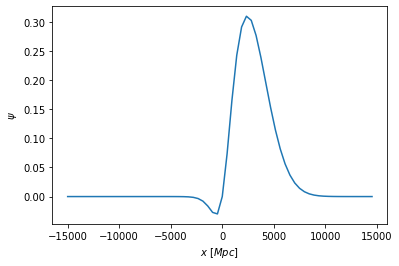

In [7]:
from scipy.signal import windows

psi_i_x = A/r_H*(zz - x_c) + B/(r_H**2)*(zz - x_c)**2
use_window = 1

if not use_window: 
    psi_i_x[np.where(zz<x_c)] = 0
else:  # yg debug
    def smooth_step(x, x_c, width):
        return 1 / (1 + np.exp(-(x - x_c) / width))

    # Calculate the smooth transition mask
    smooth_mask = smooth_step(zz, x_c, 500)

    # Apply the smooth transition to psi_i_x
    psi_i_x *= smooth_mask


if use_window:
    window_type = 'gaussian'
    if window_type == 'hann':
        wz = windows.hann(grid)
    elif window_type == 'gaussian':
        wz = windows.gaussian(grid, std=grid/12)
    print(wz)
    window = wz[np.newaxis,np.newaxis,:]
else:
    window = 1

print(direction)
if direction == 'x':
    plt.plot(x,psi_i_x[:, 0, 0])

elif direction == 'y':
    plt.plot(x,psi_i_x[0, :, 0])

elif direction == 'z':
    plt.plot(x,(window*psi_i_x)[0, 0, :])

plt.xlabel(r'$x\ [Mpc]$')
plt.ylabel(r'$\psi$')

In [8]:
psi_i_x = window*psi_i_x
psi_i_k = np.fft.fftn(psi_i_x)
print(psi_i_k.shape)

(64, 64, 64)


In [9]:
if 0:
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    
    fig.colorbar(ax.scatter(xx,yy,zz,c=psi_i_x, s=0.01))
    ax.set_xlabel(r'x')
    ax.set_ylabel(r'y')
    ax.set_zlabel(r'z')
    ax.set_title(r'$\Psi_{i} (\mathbf{x})$');

# Choose the Ze of remote dipole field

In [10]:
r_e = remote_spectra.chifromz(Z_e)
r_edec = remote_spectra.chifromz(config.zdec) - remote_spectra.chifromz(Z_e)
r_dec = remote_spectra.chifromz(config.zdec)

print(f'r_c = {x_c} Mpc')
print(f'r_e = {r_e} Mpc')
print(f'r_edec = {r_edec} Mpc')
print(f'r_dec = {r_dec} Mpc')
print(f'r_H = {r_H} Mpc')

r_c = 0.0 Mpc
r_e = 3383.0757384546937 Mpc
r_edec = 10457.993152490668 Mpc
r_dec = 13841.068890945362 Mpc
r_H = 4411.764705882353 Mpc


In [11]:
import my_remote_spectra
importlib.reload(my_remote_spectra)
from my_remote_spectra import T, G_SW_ksz, G_localDopp_ksz, G_Dopp_ksz, G_ISW_ksz

In [12]:
do_gradient = True
if do_gradient:
    Edge_order=2   
    g_psi_i_x = np.array([np.gradient(psi_i_x, d, edge_order=Edge_order)[1], np.gradient(psi_i_x, d, edge_order=Edge_order)[0], np.gradient(psi_i_x, d, edge_order=Edge_order)[2]])
#     g_psi_i_x = np.array([np.gradient(psi_i_x, d, edge_order=Edge_order)[0], np.gradient(psi_i_x, d, edge_order=Edge_order)[1], np.gradient(psi_i_x, d, edge_order=Edge_order)[2]])

else:
    g_psi_i_x3 = A/r_H + 2*B/(r_H**2)*(zz - x_c)
    g_psi_i_x3[np.where(zz<x_c)] = 0
    g_psi_i_x = np.array([np.zeros(xx.shape), np.zeros(xx.shape), g_psi_i_x3])

if 1:
    g_psi_i_k = np.array([np.fft.fftn(g_psi_i_x[0]), np.fft.fftn(g_psi_i_x[1]), np.fft.fftn(g_psi_i_x[2])])
else: # yg debug
    g_psi_i_k = np.array([psi_i_k * kk_x*1j, psi_i_k*kk_y*1j, psi_i_k * kk_z*1j])

z


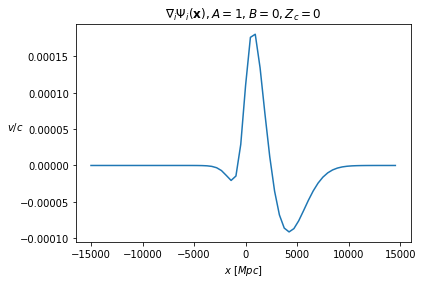

In [13]:
if 1:
    print(direction)
    if direction == 'x':
        plt.plot(x,g_psi_i_x[0].real[0, :, 0]) 
    elif direction == 'y':
        plt.plot(x,g_psi_i_x[1].real[:, 0, 0]) 
    elif direction == 'z':
        # V_eff_SW_x3.real = np.abs(V_eff_SW_x3.real)
        plt.plot(x,g_psi_i_x[2].real[0, 0, :])
#         plt.plot(x,np.abs(g_psi_i_k[2])[0, 0, :])
#         plt.plot(x,np.abs(psi_i_k[2]*kk_z)[0, 0, :])


#         print(g_psi_i_x[2].real[0, 0, :])
    
    plt.title(r'$\nabla_i\Psi_{i} (\mathbf{x}), A=%s, B=%s, Z_{c}=%s$'%(A, B, z_c));
    plt.xlabel(r'$x\ [Mpc]$')
    plt.ylabel(r'$v/c$', rotation=0)

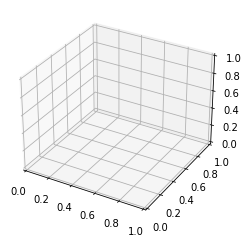

In [14]:
# try to plot the sphere on heapix plot
# https://healpy.readthedocs.io/en/latest/tutorial.html
NSIDE = 64
NPIX = hp.nside2npix(NSIDE)

theta_deg, phi_deg = np.degrees(hp.pix2ang(nside=NSIDE, ipix=np.arange(NPIX)))
theta = theta_deg * pi / 180.0
phi = phi_deg * pi / 180.0

x_e = r_e*np.sin(theta)*np.cos(phi) #Mpc
y_e = r_e*np.sin(theta)*np.sin(phi) #Mpc
z_e = r_e*np.cos(theta) #Mpc

if 0:
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')

    ax.scatter(x_e,y_e,z_e, s=0.2)
    # ax.set_xlim([-r_o, r_o])
    # ax.set_ylim([-r_o, r_o])
    # ax.set_zlim([-r_o, r_o])
    ax.set_xlabel(r'x')
    ax.set_ylabel(r'y')
    ax.set_zlabel(r'z')
    # ax.view_init(90, -90) 

# see https://stackoverflow.com/questions/11140163/plotting-a-3d-cube-a-sphere-and-a-vector and \
# https://stackoverflow.com/questions/64656951/plotting-spheres-of-radius-r
# check https://stackoverflow.com/questions/11140163/plotting-a-3d-cube-a-sphere-and-a-vector
# Z_e = 2
# a_e = 1/(1+Z_e)
# firstly obtain all the points at r_e = tau(a=1)-tau(a=a_e)
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# then plot the LSS for an electron at this sphere and the LSS for us
# pick a certain point at the sphere with coordinate of (a_e, x_e, y_e, z_e)

x_edec_s = r_edec*np.sin(theta)*np.cos(phi)
y_edec_s = r_edec*np.sin(theta)*np.sin(phi)
z_edec_s = r_edec*np.cos(theta)
# ax.scatter(x_e,y_e,z_e, color='r', s=10)

# get r_dec
# u, v = np.mgrid[0:2*np.pi:20j, 0:np.pi:20j]
x_dec_s = r_dec*np.sin(theta)*np.cos(phi)
y_dec_s = r_dec*np.sin(theta)*np.sin(phi)
z_dec_s = r_dec*np.cos(theta)

if 0:
    ax.scatter(x_e, y_e, z_e, alpha=0.4, label=r'$r_{e}$', s=0.01)
    ax.scatter(x_edec_s+x_e[0], y_edec_s+y_e[0], z_edec_s+z_e[0], alpha=0.4, label=r'$r_{edec}$', s=0.01)
    ax.scatter(x_dec_s, y_dec_s, z_dec_s, color='y', alpha=0.4, label=r'$r_{dec}$', s=0.01)
    ax.scatter(0,0,0, color='k', s=1)
    ax.scatter(x_e[0],y_e[0],z_e[0], color='r', s=2)
    
    
    yy_c, zz_c = np.meshgrid(y, z)
    xx_c = x_c*np.ones_like(yy_c)
    if direction == 'x':
        ax.plot_surface(xx_c, yy_c, zz_c, alpha=0.2)
    if direction == 'y':
        ax.plot_surface(yy_c, xx_c, zz_c, alpha=0.2)
    elif direction == 'z':
        ax.plot_surface(yy_c, zz_c, xx_c, alpha=0.2)
    
    ax.set_xlim([-BoxSize/2, BoxSize/2])
    ax.set_ylim([-BoxSize/2, BoxSize/2])
    ax.set_zlim([-BoxSize/2,BoxSize/2])
    ax.set_xlabel(r'x [Mpc]')
    ax.set_ylabel(r'y [Mpc]')
    ax.set_zlabel(r'z [Mpc]')
    ax.set_title(r'$V_{eff, r}(\mathbf{x}, r_e), A=%s, B=%s, Z_{c}=%s, Z_{e}=%s$'%(A, B, z_c, Z_e))
    ax.legend()
    ax.view_init(0, -90) 

In [15]:
import my_tools
importlib.reload(my_tools)
from my_tools import Evolve

EV = Evolve(kk, Z_e, Omega_b, Omega_c, w, wa, Omega_K, h)
use_GradientEvolve = True
if 1: use_GradientEvolve = False  # yg debug


if use_GradientEvolve:
    RDF_localDopp_3d = EV.RDF_g_Evolve('localDopp', g_psi_i_k)
    RDF_Dopp_3d = EV.RDF_g_Evolve('Dopp', g_psi_i_k)
    RDF_SW_3d = EV.RDF_g_Evolve('SW', g_psi_i_k)
    RDF_ISW_3d = EV.RDF_g_Evolve('ISW', g_psi_i_k)
else:
    RDF_localDopp_3d = EV.RDF_Evolve('localDopp', psi_i_k, [kk_x, kk_y, kk_z])
    RDF_Dopp_3d = EV.RDF_Evolve('Dopp', psi_i_k, [kk_x, kk_y, kk_z])
    RDF_SW_3d = EV.RDF_Evolve('SW', psi_i_k, [kk_x, kk_y, kk_z])
    RDF_ISW_3d = EV.RDF_Evolve('ISW', psi_i_k, [kk_x, kk_y, kk_z])


/cita/h/home-2/yguan/work/uoft/remote_quadrapole/ReCCO/code/my_tools.py:40: RuntimeWarning: invalid value encountered in divide
  dir_x = 1j*kk_component[0]/self.kk
/cita/h/home-2/yguan/work/uoft/remote_quadrapole/ReCCO/code/my_tools.py:42: RuntimeWarning: invalid value encountered in divide
  dir_y = 1j*kk_component[1]/self.kk
/cita/h/home-2/yguan/work/uoft/remote_quadrapole/ReCCO/code/my_tools.py:44: RuntimeWarning: invalid value encountered in divide
  dir_z = 1j*kk_component[2]/self.kk


0.9358486818539136
0.8596994270419701


Text(0, 0.5, '$v/c$')

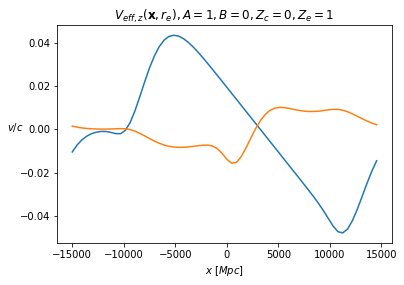

In [16]:
a_dec = kszpsz_config.adec
D_psi_dec = remote_spectra.Dpsi_inter(Omega_b, Omega_c, w, wa, Omega_K, h)(a_dec)
D_psi_e = remote_spectra.Dpsi_inter(Omega_b, Omega_c, w, wa, Omega_K, h)(a_e)
print(D_psi_dec)
print(D_psi_e)

# evolve_factor = 3*(2*D_psi_e - 3/2)
SW_factor = 0.52
delta_RDF_SW_3d = SW_factor*psi_i_x.mean()

ISW_factor = -0.122
delta_RDF_ISW_3d = ISW_factor*psi_i_x.mean()

# RDF_SW_3d[2] = RDF_SW_3d[2] + delta_RDF_SW_3d
# RDF_ISW_3d[2] = RDF_ISW_3d[2] + delta_RDF_ISW_3d
plt.plot(x, RDF_SW_3d[2].real[0, 0, :], label='SW')
plt.plot(x, RDF_ISW_3d[2].real[0, 0, :], label='ISW')
plt.title(r'$V_{eff,z}(\mathbf{x}, r_e), A=%s, B=%s, Z_{c}=%s, Z_{e}=%s$'%(A, B, z_c, Z_e));
plt.xlabel(r'$x\ [Mpc]$')
plt.ylabel(r'$v/c$', rotation=0)

Text(0, 0.5, '$v/c$')

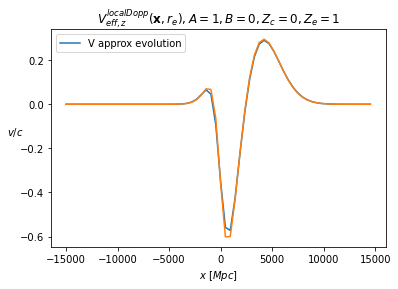

In [17]:
D_v = remote_spectra.Dv_inter(Omega_b, Omega_c, w, wa, Omega_K, h)(a_e)
plt.plot(x,-g_psi_i_x[2][0, 0, :]*D_v, label='V approx evolution')

plt.plot(x, RDF_localDopp_3d[2].real[0, 0, :])
plt.title(r'$V^{localDopp}_{eff,z}(\mathbf{x}, r_e), A=%s, B=%s, Z_{c}=%s, Z_{e}=%s$'%(A, B, z_c, Z_e));
plt.legend()
plt.xlabel(r'$x\ [Mpc]$')
plt.ylabel(r'$v/c$', rotation=0)

In [18]:
RDF_localDopp_2d = EV.ThreeDVec_Projection((x, y, z), RDF_localDopp_3d.real, (x_e, y_e, z_e))
RDF_Dopp_2d = EV.ThreeDVec_Projection((x, y, z), RDF_Dopp_3d.real, (x_e, y_e, z_e))
RDF_SW_2d = EV.ThreeDVec_Projection((x, y, z), RDF_SW_3d.real, (x_e, y_e, z_e))
RDF_ISW_2d = EV.ThreeDVec_Projection((x, y, z), RDF_ISW_3d.real, (x_e, y_e, z_e))

RDF_localDopp_2d_radial = EV.ThreeDVec_Projection_Radial((x, y, z), RDF_localDopp_3d.real, (x_e, y_e, z_e), (theta, phi))
RDF_Dopp_2d_radial = EV.ThreeDVec_Projection_Radial((x, y, z), RDF_Dopp_3d.real, (x_e, y_e, z_e), (theta, phi))
RDF_SW_2d_radial = EV.ThreeDVec_Projection_Radial((x, y, z), RDF_SW_3d.real, (x_e, y_e, z_e), (theta, phi))
RDF_ISW_2d_radial = EV.ThreeDVec_Projection_Radial((x, y, z), RDF_ISW_3d.real, (x_e, y_e, z_e), (theta, phi))

In [19]:
# check https://stackoverflow.com/questions/11140163/plotting-a-3d-cube-a-sphere-and-a-vector
if 0:
    print(direction)
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    fig.colorbar(ax.scatter(x_e, y_e, z_e, c=RDF_localDopp_2d[2], alpha=0.4, label=r'$r_{edec}$', s=0.2))
    # fig.colorbar(ax.scatter(x_e, y_e, z_e, c=V_eff_SW_radial_chi, alpha=0.4, label=r'$r_{edec}$', s=0.2));
    # ax.scatter(x_e,y_e,z_e, color='r', s=10)
    ax.set_xlabel(r'x [Mpc]')
    ax.set_ylabel(r'y [Mpc]')
    ax.set_zlabel(r'z [Mpc]')
    ax.set_title(r'$V^{localDopp}_{eff, z}(\mathbf{x}, r_e), A=%s, B=%s, Z_{c}=%s, Z_{e}=%s$'%(A, B, z_c, Z_e));
    
    # check xy direction np.cos(theta)view
    # ax.view_init(0, -90) 
    # ax.view_init(90, -90) 
    # ==========   ====  ====
    # view plane   elev  azim
    # ==========   ====  ====
    # XY           90    -90
    # XZ           0     -90
    # YZ           0     0
    # -XY          -90   90
    # -XZ          0     90
    # -YZ          0     180
    # ==========   ====  ====

In [20]:
# check https://stackoverflow.com/questions/11140163/plotting-a-3d-cube-a-sphere-and-a-vector
if 0:
    print(direction)
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    fig.colorbar(ax.scatter(x_e, y_e, z_e, c=RDF_localDopp_2d_radial, alpha=0.4, label=r'$r_{edec}$', s=0.2))
    ax.set_xlabel(r'x [Mpc]')
    ax.set_ylabel(r'y [Mpc]')
    ax.set_zlabel(r'z [Mpc]')
    ax.set_title(r'$V^{localDopp}_{eff, r}(\mathbf{x}, r_e), A=%s, B=%s, Z_{c}=%s, Z_{e}=%s$'%(A, B, z_c, Z_e));

# Check 1D symmetries

In [21]:
theta_e_deg_1d = np.arange(0,180,1)
phi_e_deg_1d = 0
    
theta_e_1d = theta_e_deg_1d * pi / 180.0
phi_e_1d = phi_e_deg_1d * pi / 180.0
    
x_e_1d = r_e*np.sin(theta_e_1d)*np.cos(phi_e_1d)
y_e_1d = r_e*np.sin(theta_e_1d)*np.sin(phi_e_1d)
z_e_1d = r_e*np.cos(theta_e_1d)


RDF_localDopp_1d = EV.ThreeDVec_Projection((x, y, z), RDF_localDopp_3d.real, (x_e_1d, y_e_1d, z_e_1d))
RDF_Dopp_1d = EV.ThreeDVec_Projection((x, y, z), RDF_Dopp_3d.real, (x_e_1d, y_e_1d, z_e_1d))
RDF_SW_1d = EV.ThreeDVec_Projection((x, y, z), RDF_SW_3d.real, (x_e_1d, y_e_1d, z_e_1d))
RDF_ISW_1d = EV.ThreeDVec_Projection((x, y, z), RDF_ISW_3d.real, (x_e_1d, y_e_1d, z_e_1d))

RDF_localDopp_1d_radial = EV.ThreeDVec_Projection_Radial((x, y, z), RDF_localDopp_3d.real, (x_e_1d, y_e_1d, z_e_1d), (theta_e_1d, phi_e_1d))
RDF_Dopp_1d_radial = EV.ThreeDVec_Projection_Radial((x, y, z), RDF_Dopp_3d.real, (x_e_1d, y_e_1d, z_e_1d), (theta_e_1d, phi_e_1d))
RDF_SW_1d_radial = EV.ThreeDVec_Projection_Radial((x, y, z), RDF_SW_3d.real, (x_e_1d, y_e_1d, z_e_1d), (theta_e_1d, phi_e_1d))
RDF_ISW_1d_radial = EV.ThreeDVec_Projection_Radial((x, y, z), RDF_ISW_3d.real, (x_e_1d, y_e_1d, z_e_1d), (theta_e_1d, phi_e_1d))

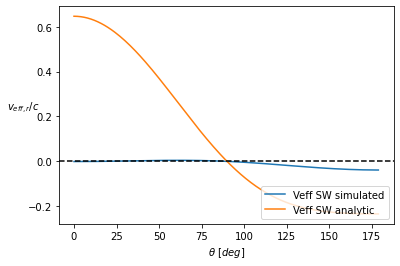

In [22]:
import bubble_collision as bc
importlib.reload(bc)

BC = bc.BubbleCollision_Veff(A, B, z_c, Z_e, Omega_b, Omega_c, w, wa, Omega_K, h)

plt.plot(theta_e_deg_1d, RDF_SW_1d_radial, label='Veff SW simulated')
plt.plot(theta_e_deg_1d, BC.Approx_Veff_SW_radial(theta_e_1d), label='Veff SW analytic')
plt.xlabel(r'$\theta\ [deg]$')
plt.ylabel(r'$v_{eff, r}/c$', rotation=0)
plt.legend(loc='lower right')
plt.axhline(y=0, c='k', linestyle='--')

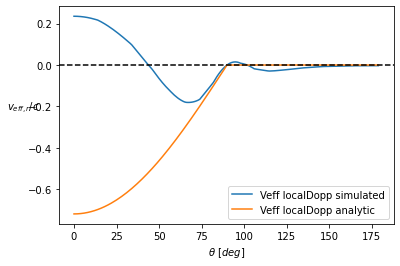

In [23]:
import bubble_collision as bc
importlib.reload(bc)

BC = bc.BubbleCollision_Veff(A, B, z_c, Z_e, Omega_b, Omega_c, w, wa, Omega_K, h)

plt.plot(theta_e_deg_1d, RDF_localDopp_1d_radial, label='Veff localDopp simulated')
plt.plot(theta_e_deg_1d, BC.Approx_Veff_localDopp_radial(theta_e_1d), label='Veff localDopp analytic')
plt.xlabel(r'$\theta\ [deg]$')
plt.ylabel(r'$v_{eff, r}/c$', rotation=0)
plt.legend(loc='lower right')
plt.axhline(y=0, c='k', linestyle='--')

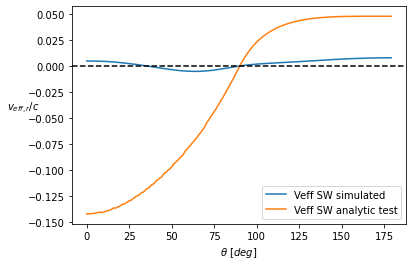

In [24]:
import bubble_collision as bc
importlib.reload(bc)

BC = bc.BubbleCollision_Veff(A, B, z_c, Z_e, Omega_b, Omega_c, w, wa, Omega_K, h)
plt.plot(theta_e_deg_1d, RDF_ISW_1d_radial, label='Veff SW simulated')
plt.plot(theta_e_deg_1d, BC.Approx_Veff_ISW_radial(theta_e_1d), label='Veff SW analytic test')
plt.xlabel(r'$\theta\ [deg]$')
plt.ylabel(r'$v_{eff, r}/c$', rotation=0)
plt.legend(loc='lower right')
plt.axhline(y=0, c='k', linestyle='--')

Text(0.5, 1.0, '$A=1, B=0, Z_{c}=0, Z_{e}=1$')

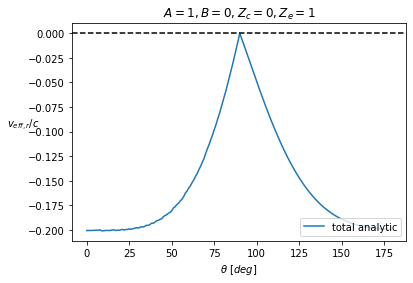

In [25]:
import bubble_collision as bc
importlib.reload(bc)

BC = bc.BubbleCollision_Veff(A, B, z_c, Z_e, Omega_b, Omega_c, w, wa, Omega_K, h)

plt.plot(theta_e_deg_1d, BC.Approx_Veff_radial(theta_e_1d), label='total analytic')
plt.xlabel(r'$\theta\ [deg]$')
plt.ylabel(r'$v_{eff, r}/c$', rotation=0)
plt.legend(loc='lower right')
plt.axhline(y=0, c='k', linestyle='--')
plt.title(r'$A=%s, B=%s, Z_{c}=%s, Z_{e}=%s$'%(A, B, z_c, Z_e))

In [26]:
import bubble_collision as bc
importlib.reload(bc)
BC = bc.BubbleCollision_Veff(A, B, z_c, Z_e, Omega_b, Omega_c, w, wa, Omega_K, h)

Text(0.5, 1.0, '$A=1, B=0, Z_{c}=0, Z_{e}=1$')

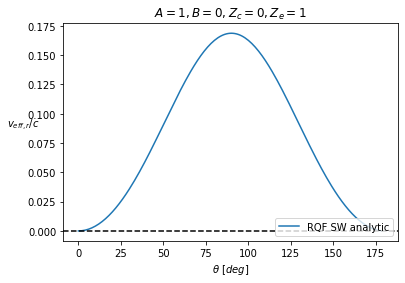

In [27]:
plt.plot(theta_e_deg_1d, BC.Approx_RQF_SW(theta_e_1d), label='RQF SW analytic')

plt.xlabel(r'$\theta\ [deg]$')
plt.ylabel(r'$v_{eff, r}/c$', rotation=0)
plt.legend(loc='lower right')
plt.axhline(y=0, c='k', linestyle='--')
plt.title(r'$A=%s, B=%s, Z_{c}=%s, Z_{e}=%s$'%(A, B, z_c, Z_e))

Text(0.5, 1.0, '$A=1, B=0, Z_{c}=0, Z_{e}=1$')

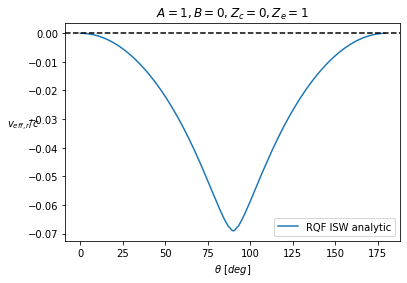

In [28]:
plt.plot(theta_e_deg_1d, BC.Approx_RQF_ISW(theta_e_1d), label='RQF ISW analytic')

plt.xlabel(r'$\theta\ [deg]$')
plt.ylabel(r'$v_{eff, r}/c$', rotation=0)
plt.legend(loc='lower right')
plt.axhline(y=0, c='k', linestyle='--')
plt.title(r'$A=%s, B=%s, Z_{c}=%s, Z_{e}=%s$'%(A, B, z_c, Z_e))

Text(0.5, 1.0, '$A=1, B=0, Z_{c}=0, Z_{e}=1$')

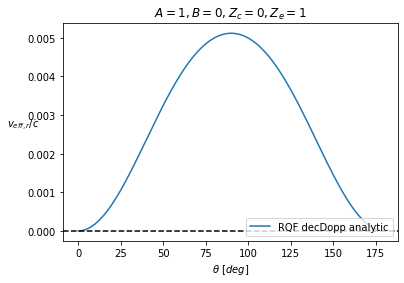

In [29]:
plt.plot(theta_e_deg_1d, BC.Approx_RQF_decDopp(theta_e_1d), label='RQF decDopp analytic')

plt.xlabel(r'$\theta\ [deg]$')
plt.ylabel(r'$v_{eff, r}/c$', rotation=0)
plt.legend(loc='lower right')
plt.axhline(y=0, c='k', linestyle='--')
plt.title(r'$A=%s, B=%s, Z_{c}=%s, Z_{e}=%s$'%(A, B, z_c, Z_e))